In [ ]:
On google colab: https://colab.research.google.com/drive/13I2odRbBoXp0XJddL2S-KvNG7CpeCuvE?usp=sharing

In [13]:
pip install requests networkx matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


Connect to the wikipedia API

In [1]:
#Load the cache
import json
import os
global cache
cache = {}
if os.path.exists("connections_cache.json"):
    with open("connections_cache.json", "r", encoding="utf-8") as f:
        cache = json.load(f)


In [7]:
import requests

def FindConnections(name):
    S = requests.Session()
    list_of_connections = []
    URL = "https://en.wikipedia.org/w/api.php"

    PARAMS = {
        "action": "query",
        "format": "json",
        "titles": name,
        "prop": "links",
        "pllimit": "max"
    }

    R = S.get(url=URL, params=PARAMS)
    DATA = R.json()

    PAGES = DATA["query"]["pages"]

    for k, v in PAGES.items():
        if "links" in v:
            for l in v["links"]:
                list_of_connections.append(l["title"])
    return list_of_connections

In [16]:
import os
import json
from collections import deque

def FindShortestPath(start, end, max_depth=5):
    queue = deque()
    queue.append((start, [start]))
    visited = set()
    while queue:
        current_article, path = queue.popleft()
        if current_article == end:
            return path
        if len(path)> max_depth:
            continue
        visited.add(current_article)
        #print(current_article) # this print statement is neccessary for some reason the code does not work without it
        # Use cache to avoid repeated requests
        if current_article in cache:
            connections = cache[current_article]
        else:
            try:
                connections = FindConnections(current_article)
                cache[current_article] = connections
                # Save cache after each new article is explored
                with open("connections_cache.json", "w", encoding="utf-8") as f:
                    json.dump(cache, f, ensure_ascii=False, indent=2)
            except Exception as e:
                continue
        for conn in connections:
            if conn not in visited:
                queue.append((conn, path + [conn]))

    return None

['Dog', 'Abyssinian genet', 'Wolf']


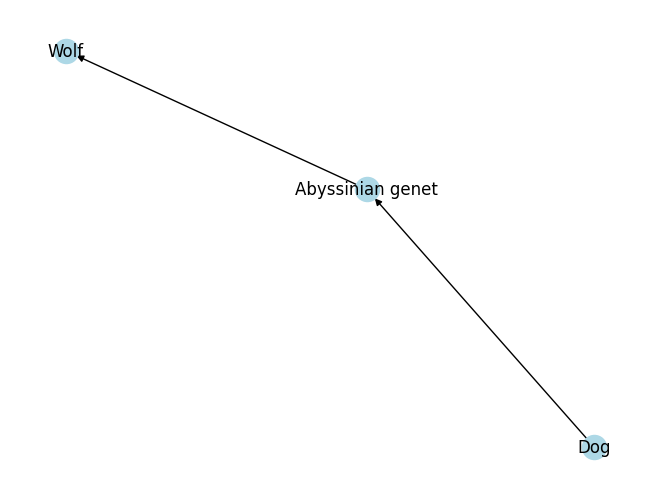

In [17]:
start_page = "Dog" #@param {type: "string"}
end_page = "Wolf" #@param {type: "string"}
max_depth = 3 #@param {type: "integer"}
path = FindShortestPath(start_page, end_page, max_depth=3)
print(path)



#Show connection
import networkx as nx
import matplotlib.pyplot as plt

D = nx.DiGraph()

for i in range(len(path)-1):
    D.add_edge(path[i], path[i+1])

nx.draw(D, with_labels=True, node_color='lightblue', arrows=True)

KeyboardInterrupt: 

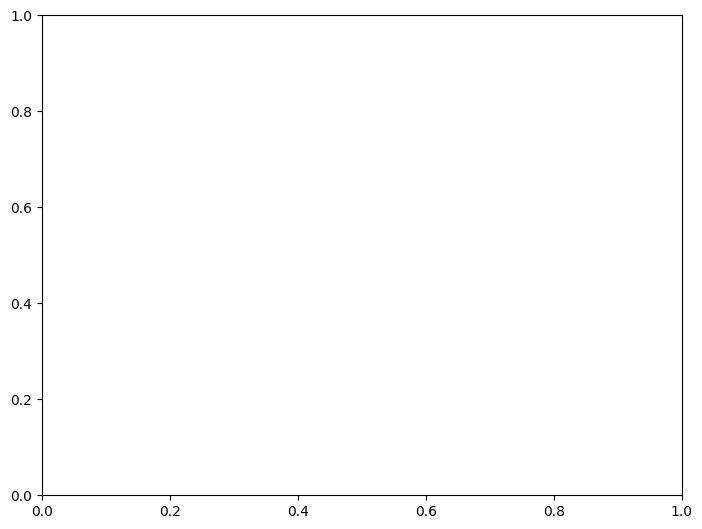

In [14]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for node, neighbors in cache.items():
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

nx.draw(G, with_labels=True, node_color='lightblue', arrows=True)
plt.show()